<a href="https://colab.research.google.com/github/JoseAlberto88/Predictive-Maintenance-Dataset/blob/main/Predictive_Maintenance_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DAMO-510-8. Predictive Analytics
## Take-Home Assignment 2: Predictive Maintenance. Machine Failure Prediction


**Course:** Predictive Analytics (DAMO-510-8)

**Term:** Summer 2026

**Instructor:** Prof. Payman Janbakhsh

**Student:** Jose Alberto Martinez Morales

---

## Background

Unexpected machine failures can cause production delays, increased maintenance costs, safety concerns, and operational disruption. Predictive analytics can support maintenance planning by identifying machines that exhibit operating conditions associated with a higher risk of failure.

In this assignment, you will develop and critically evaluate classification models using the AI4I 2020 Predictive Maintenance Dataset.

The purpose of this assignment is not simply to obtain the highest model accuracy. You are expected to demonstrate appropriate analytical judgement regarding data preparation, variable selection, class imbalance, model development, evaluation, interpretation, and operational decision-making.

## Dataset

Use the AI4I 2020 Predictive Maintenance Dataset from the UCI Machine Learning Repository:

https://archive.ics.uci.edu/dataset/601/ai4i+2020+predictive+maintenance+dataset

**Target variable:** `Machine failure`

You must use the original dataset obtained from the stated source.


In [1]:
# For this assignment, I will save the Maintenance Dataset in my Google drive and call it using code.
# If you want to run the jupyter notebook in your local machine, please change the directory described in the next code block.

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

DATA_FILE = '/content/drive/MyDrive/Predictive Analytics Course/Maintenance Dataset.csv'
df = pd.read_csv(DATA_FILE)

# To check the 5 first observations of the dataset
print("Initial shape:", df.shape)
df.head()

Initial shape: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## Assignment Tasks

### Task 1. Problem Definition

Define the predictive problem represented by the dataset.

Your discussion must:

- clearly identify the target variable and classes;
- explain the purpose of predicting machine failure;
- identify potential users of such a prediction system;
- distinguish between the operational consequences of false-positive and false-negative predictions; and
- identify the evaluation criteria you believe should receive the greatest emphasis in this problem.

Support your choices using the context of predictive maintenance rather than generic definitions of classification.

### Task 1. Problem Definition

#### **Explanation: Target Variables and Classes**
The AI4I 2020 dataset frames a binary classification problem centred on the variable **Machine failure**, which takes the value 1 when a machine tool has experienced at least one of five recorded failure modes during an operating cycle (tool wear failure, heat dissipation failure, power failure, overstrain failure, or random failure) and 0 when it has not. Of the 10,000 recorded observations, failures are a small minority of cases, which already signals that this is a rare-event detection problem rather than a balanced discrimination task, a point that shapes every later modelling decision, from the choice of resampling strategy to the metrics used to judge success.

#### **Explanation: Purpose of Predicting Machine Failure**
The purpose of predicting machine failure is to shift maintenance activity away from the two conventional regimes that dominate manufacturing operations. Purely reactive maintenance repairs a machine only after it has broken, which guarantees unplanned downtime, and time-based preventive maintenance services equipment on a fixed schedule regardless of its actual condition, which wastes labour and parts on machines that did not need attention while still missing failures that occur between scheduled visits. A predictive model that flags an elevated failure risk from live operating conditions, such as temperatures, rotational speed, torque, and tool wear,  allows maintenance to be triggered by the actual state of the machine rather than by the calendar or by failure itself, which is the basic value proposition of condition-based, predictive maintenance.


#### **Identification: Potential Users of such a Prediction System**
The natural users of such a system are the people who plan and execute maintenance work rather than the data science team that builds it: maintenance and reliability engineers who would use the model's output to prioritise inspection queues, production planners and plant managers who need advance warning to schedule downtime without disrupting delivery commitments, shop-floor technicians who would receive an operational alert rather than a probability score, and, indirectly, safety personnel, since several of the underlying failure modes (heat dissipation, overstrain) are also safety-relevant conditions. In practice, the model's output would most plausibly be consumed through a maintenance dashboard or a computerised maintenance management system (CMMS) rather than read directly as raw model output.

#### **Distintion: False-Positive and False-Negative Predictions**
Because this is a binary decision problem applied to a physical process, the two error types are not interchangeable, and treating them as symmetric would misrepresent the operational reality the model is meant to serve. A **false positive**, it means the model predicts failure when the machine is in fact healthy, triggers an unnecessary inspection or maintenance stoppage. This has a real but bounded cost: lost production time, technician labour, and, if false alarms are frequent, an erosion of operator trust that can lead staff to start ignoring the system altogether (alarm fatigue), which would defeat its purpose over time. A **false negative**, it means the model predicts no failure when the machine is about to fail, is materially more costly in most predictive-maintenance settings: it means the failure is discovered only when it actually occurs, with the same unplanned downtime, cascading equipment damage, and safety exposure that predictive maintenance was introduced to avoid, plus the reputational cost of a system that failed to warn when it was supposed to. Because the dataset also implies a low base rate of failure, the asymmetry compounds: with failures scarce and their cost to miss high, a model that defaults toward the majority "no failure" prediction can look accurate while providing little of the protection the business actually needs.

#### **Identification and Evaluation Criteria**
This asymmetry is what should drive the choice of evaluation criteria, and it argues against using overall accuracy as the primary yardstick, since with failures forming a small share of observations a trivial always-predict-no-failure model would already score highly on accuracy while being operationally useless. The metric that should receive the greatest emphasis is **recall on the failure class** (the proportion of actual failures the model successfully flags), because in this problem missing a failure is more expensive than issuing an avoidable inspection. Recall should not be optimised in isolation, however: a model that maximises recall by flagging almost everything as high-risk would generate so many false alarms that maintenance staff could not act on them meaningfully, so **precision** and a metric that balances the two (F1, or an F-beta score that weights recall above precision to reflect the cost asymmetry) should be tracked alongside it, together with a threshold-independent measure such as **ROC-AUC** to assess the model's underlying ability to separate failing from healthy machines before any specific operating threshold is chosen. This combination, recall-weighted performance on the minority class, checked against precision to keep false alarms manageable, and summarised by a threshold-independent ranking metric, reflects how the model would actually be judged and operated in a predictive-maintenance context, rather than how a classifier is conventionally scored in a balanced, generic setting.


### Task 2. Data Audit

Conduct an audit of the original dataset.

Your submission must provide evidence regarding:

- dataset dimensions;
- variable types;
- target distribution;
- missing information;
- duplicate observations;
- unusual or potentially problematic values;
- categorical and numerical predictors;
- identifier-like variables; and
- any variables that may create data leakage.

Determine which variables should and should not be included in your predictive model. You must justify all exclusions.

Special attention must be given to: **TWF, HDF, PWF, OSF, and RNF**.

Simply removing these variables without explaining your reasoning is insufficient.

#### **Dimensions, types, target distribution:**

In [10]:
# Dataset dimentions
print("Shape (rows, columns):", df.shape)

# Variballe types
print(df.dtypes)
df.info()

# target distribution
print(df['Machine failure'].value_counts())
print(df['Machine failure'].value_counts(normalize=True) * 100)

Shape (rows, columns): (10000, 14)
UDI                          int64
Product ID                  object
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K] 

#### **Missing values and duplicates**

In [16]:
# Missing information
missing_summary = pd.DataFrame({
    'missing_count' : df.isnull().sum(),
    'missing_pct' : (df.isnull().mean() * 100).round(2)
})

print(missing_summary)

# Duplicates observations
print("Fully duplicated rows:", df.duplicated().sum())
print("Duplicate UDI values:", df['UDI'].duplicated().sum())
print("Duplicate Product ID values:", df['Product ID'].duplicated().sum())

feature_cols = df.columns.difference(['UDI', 'Product ID'])

print("Duplicate feature combos (excl. identifiers):", df.duplicated(subset=feature_cols).sum())

                         missing_count  missing_pct
UDI                                  0          0.0
Product ID                           0          0.0
Type                                 0          0.0
Air temperature [K]                  0          0.0
Process temperature [K]              0          0.0
Rotational speed [rpm]               0          0.0
Torque [Nm]                          0          0.0
Tool wear [min]                      0          0.0
Machine failure                      0          0.0
TWF                                  0          0.0
HDF                                  0          0.0
PWF                                  0          0.0
OSF                                  0          0.0
RNF                                  0          0.0
Fully duplicated rows: 0
Duplicate UDI values: 0
Duplicate Product ID values: 0
Duplicate feature combos (excl. identifiers): 0


#### **Unusual/problematic values (physical plausibility plus outliers)**



In [21]:
numeric_cols = ["Air temperature [K]", "Process temperature [K]",
                 "Rotational speed [rpm]", "Torque [Nm]", "Tool wear [min]"]
print(df[numeric_cols].describe().T)

print("Negative values:\n", (df[numeric_cols] == 0).sum())

print("Zero values:\n", (df[numeric_cols] == 0).sum())
print("Process temp <= Air temp rows:", (df['Process temperature [K]'] <= df['Air temperature [K]']).sum())

print(df['Type'].value_counts())

for col in numeric_cols:
  q1, q3 = df[col].quantile([0.25, 0.75])
  iqr = q3 - q1
  lower = q1 - 1.5 * iqr
  upper = q3 + 1.5 * iqr
  n_out = ((df[col] < lower) | (df[col] > upper)).sum()
  print(f"{col}: {n_out} IQR outliers")

                           count        mean         std     min     25%  \
Air temperature [K]      10000.0   300.00493    2.000259   295.3   298.3   
Process temperature [K]  10000.0   310.00556    1.483734   305.7   308.8   
Rotational speed [rpm]   10000.0  1538.77610  179.284096  1168.0  1423.0   
Torque [Nm]              10000.0    39.98691    9.968934     3.8    33.2   
Tool wear [min]          10000.0   107.95100   63.654147     0.0    53.0   

                            50%     75%     max  
Air temperature [K]       300.1   301.5   304.5  
Process temperature [K]   310.1   311.1   313.8  
Rotational speed [rpm]   1503.0  1612.0  2886.0  
Torque [Nm]                40.1    46.8    76.6  
Tool wear [min]           108.0   162.0   253.0  
Negative values:
 Air temperature [K]          0
Process temperature [K]      0
Rotational speed [rpm]       0
Torque [Nm]                  0
Tool wear [min]            120
dtype: int64
Zero values:
 Air temperature [K]          0
Process temp

#### **Identifier check:**



In [22]:
# Identifier like variables
print("Unique UDI:", df['UDI'].nunique(), "of", len(df))
print("Unique Product ID:", df['Product ID'].nunique(), "of", len(df))
print("Product ID prefix == Type in",
      (df['Product ID'].str[0] == df['Type']).mean() * 100, "% of rows")

Unique UDI: 10000 of 10000
Unique Product ID: 10000 of 10000
Product ID prefix == Type in 100.0 % of rows


#### **The leakage check for TWF, HDF, PWF, OSF, RNF**

In [23]:
leak_cols = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']

for col in leak_cols:
    print(col, "vs Machine failure:\n", pd.crosstab(df[col], df['Machine failure']))

implied_failure = (df[leak_cols].sum(axis=1) > 0).astype(int)
agreement = (implied_failure == df['Machine failure']).mean() * 100
print(f"Agreement between OR(TWF..RNF) and Machine failure: {agreement:.2f}%")

mismatch = df[implied_failure != df['Machine failure']]
print("Mismatched rows:", len(mismatch))
print(mismatch[['Machine failure'] + leak_cols].head(10))

TWF vs Machine failure:
 Machine failure     0    1
TWF                       
0                9661  293
1                   0   46
HDF vs Machine failure:
 Machine failure     0    1
HDF                       
0                9661  224
1                   0  115
PWF vs Machine failure:
 Machine failure     0    1
PWF                       
0                9661  244
1                   0   95
OSF vs Machine failure:
 Machine failure     0    1
OSF                       
0                9661  241
1                   0   98
RNF vs Machine failure:
 Machine failure     0    1
RNF                       
0                9643  338
1                  18    1
Agreement between OR(TWF..RNF) and Machine failure: 99.73%
Mismatched rows: 27
      Machine failure  TWF  HDF  PWF  OSF  RNF
1221                0    0    0    0    0    1
1302                0    0    0    0    0    1
1437                1    0    0    0    0    0
1748                0    0    0    0    0    1
2072                0

#### **Final inclusion/exclusion decision:**

In [24]:
excluded_vars = ['UDI', 'Product ID'] + leak_cols
included_predictors = ['Type'] + numeric_cols
df_model = df[included_predictors + ['Machine failure']].copy()
print(df_model.shape)
df_model.head()

(10000, 7)


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0
3,L,298.2,308.6,1433,39.5,7,0
4,L,298.2,308.7,1408,40.0,9,0


## Task 2. Data Audit Conclusion

The dataset, obtained from the UCI AI4I 2020 Predictive Maintenance repository, contains 10,000 observations and 14 variables, with no missing values in any column and no fully duplicated rows. Both identifier columns are confirmed unique (10,000 distinct UDI values and 10,000 distinct Product ID values across 10,000 rows), and re-checking duplication on the feature columns alone, i.e. ignoring the two identifiers, still returns zero duplicate rows, so no observations were removed at the audit stage.

**Variable roles.** The 14 columns fall into five functional groups, summarised below together with the audit decision reached for each:

| Group | Variables | Type | Audit decision |
|---|---|---|---|
| Identifiers | UDI, Product ID | int / object | Excluded |
| Categorical predictor | Type | object (L/M/H) | Retained |
| Numerical predictors | Air temperature [K], Process temperature [K], Rotational speed [rpm], Torque [Nm], Tool wear [min] | float / int | Retained |
| Target | Machine failure | int (0/1) | Target |
| Failure-mode flags | TWF, HDF, PWF, OSF, RNF | int (0/1) | Excluded (data leakage) |

**Target distribution.** `Machine failure` is heavily imbalanced: 9,661 observations (96.61%) are non-failures and only 339 (3.39%) are failures, a ratio of roughly 28.5 non-failures for every failure. This confirms the framing in Task 1, accuracy is a poor primary metric here, and class imbalance must be addressed explicitly in preprocessing (Task 4) and investigated directly in Task 8.

**Unusual or problematic values.** None of the five numerical predictors contain negative or otherwise physically impossible values; the minimum of Tool wear is 0, and no other numerical column takes negative values. `Tool wear [min] = 0` occurs in 120 rows, which is a legitimate reading, the simulated wear counter resets to zero whenever a tool is replaced, rather than a data error, so these rows were retained. Process temperature exceeds air temperature in all 10,000 rows, which is physically consistent with heat generated by the machining process and gives no reason to suspect corrupted sensor readings. An IQR-based check flags 418 observations (4.2%) as high-side outliers on Rotational speed and 69 (0.7%) on Torque; because these values are neither negative nor implausible for a machining process operating outside its typical band, and because extreme torque/speed combinations are plausible precursors to overstrain, and power-related failures, they were treated as genuine extreme operating points rather than errors and were not removed, this is revisited in the exploratory analysis (Task 3) as a candidate driver of failure risk rather than noise to be filtered out. The categorical `Type` column contains exactly three valid levels (L = 6,000, M = 2,997, H = 1,003) with no misspellings or stray categories.

**Identifier-like variables.** UDI is a bare sequential row index (1 to 10,000, no repeats) and carries no information about machine condition; it was excluded. Product ID is also 100% unique per row, so it functions as a serial number rather than a predictor, and its first character was found to match the `Type` column in 100% of rows, confirming that the one piece of Product ID that is not a unique serial number (its L/M/H prefix) is fully redundant with `Type`, which is retained separately. Keeping Product ID in the model would risk the model keying on individual unit identity (a form of leakage/over-identification) rather than learning generalisable operating-condition patterns, so it was excluded along with UDI.

**Data leakage: TWF, HDF, PWF, OSF, RNF.** These five binary flags record which specific failure mechanism was involved in a machine-failure event (tool wear, heat dissipation, power, overstrain, and random failures respectively), and the audit shows why they cannot be used as predictors rather than simply asserting it. Checking whether `Machine failure` equals the logical OR of the five flags gives 99.73% agreement (9,973 of 10,000 rows), and the crosstabs make clear why the flags are leakage rather than merely correlated: for TWF, HDF, PWF and OSF, *every single row* where the flag equals 1 also has `Machine failure = 1` (e.g. all 46 TWF=1 rows, all 115 HDF=1 rows, all 95 PWF=1 rows, and all 98 OSF=1 rows are failures). These four flags are, in effect, a decomposition of the positive class into its failure mechanism, not an independent measurement taken before failure occurs. Including any of them would let the model read the label off a near-identical encoding of itself rather than learn from the underlying operating conditions.

RNF (random failure) behaves differently and is worth spelling out rather than lumping in with the other four: of the 19 rows where RNF = 1, only 1 corresponds to an actual `Machine failure = 1`; the other 18 are false triggers relative to the target. This is consistent with RNF being designed as a low-probability failure mode injected independently of the process parameters, so unlike the other four flags it does not leak the target, but it also carries essentially no genuine predictive signal (a 1-in-19 hit rate is barely different from noise) and, like the others, would not be knowable in advance of the outcome it nominally flags. It is excluded for a different reason than TWF/HDF/PWF/OSF: not because it gives the answer away, but because it is uninformative and, by construction, unobservable ahead of the failure event it is meant to represent.

The 27 rows (0.27%) where `Machine failure` and OR(TWF..RNF) disagree also split into two informative patterns: the 18 RNF-only false triggers described above, and roughly 9 rows where `Machine failure = 1` but none of the five flags is set, cases such as UDI rows 1437, 2749 and 4044, where a failure is recorded with all five mode flags at 0. This indicates the five flags do not perfectly span every real failure mechanism captured in the simulation, reinforcing that they are a diagnostic sub-classification of the target rather than a set of independent, always-available predictors, and that a model should be learning failure risk from the continuous sensor variables rather than from this near-tautological encoding of the label. All five flags (TWF, HDF, PWF, OSF, RNF) are therefore excluded from the predictive model on both statistical grounds (near-total agreement with the target for four of the five) and operational grounds (none of the five would be known at the point an early-warning prediction needs to be made).

**Final variable set.** After the audit, the modelling frame retains `Type` and the five continuous sensor variables (Air temperature, Process temperature, Rotational speed, Torque, Tool wear) as predictors, with `Machine failure` as the target; UDI, Product ID, TWF, HDF, PWF, OSF and RNF are excluded for the reasons documented above.


### Task 3. Exploratory Investigation

Conduct an exploratory investigation of the predictors and the target.

Your analysis must identify **at least five findings** that could potentially affect:

- preprocessing;
- feature selection;
- model choice;
- class-imbalance treatment; or
- interpretation of the final model.

At least **two findings** must involve relationships between multiple variables rather than a single-variable distribution.

Provide appropriate supporting tables or visualizations. For every finding, explain why it matters to the predictive problem.


In [53]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Output folder on Google Drive (Colab)
# Creates a "visuals" subfolder next to the dataset and saves every figure there.
OUTPUT_DIR = '/content/drive/MyDrive/Predictive Analytics Course/visuals'
os.makedirs(OUTPUT_DIR, exist_ok=True)


def savefig(filename):
    """Save the current figure into the Drive visuals folder."""
    plt.savefig(os.path.join(OUTPUT_DIR, filename), dpi=150, bbox_inches='tight')

# ---- Shared style / palette (kept consistent across all EDA figures) ----
# Softer, pastel-leaning pair -- still validated for lightness band, chroma floor,
# and colorblind (CVD) separation; the contrast-vs-surface check lands in the WARN
# band, so every chart using these colors keeps direct value labels / a legend
# alongside the color (the required "relief" for that warning).
COLOR_NO_FAILURE = "#5b9bd5"   # pastel blue
COLOR_FAILURE    = "#e8767a"   # pastel coral/red
AXIS_COLOR       = "#c3c2b7"
TEXT_MUTED       = "#898781"
TEXT_PRIMARY     = "#0b0b0b"

# Separate categorical palette for product Type (L/M/H) -- deliberately distinct
# hues from the blue/coral failure-status pair above, so a reader never confuses
# "which Type" color with "did it fail" color across figures. Validated (3-slot
# categorical): passes lightness band, chroma floor, and CVD/normal-vision
# separation checks.
TYPE_COLORS = {
    'H': "#9c8ee0",   # pastel violet
    'L': "#2fa38a",   # pastel teal
    'M': "#d9a23b",   # pastel amber
}

# Diverging pastel blue<->coral colormap with a neutral gray midpoint, for correlation heatmaps
# (this encodes correlation polarity, not failure class, so it keeps the blue/coral
# pair above rather than switching to the green/red pair below)
DIVERGING_CMAP = LinearSegmentedColormap.from_list(
    "blue_gray_red", ["#5b9bd5", "#f0efec", "#e8767a"], N=256
)

# Stronger pastel green/red pair, used only in the multivariate scatter figures
# (3.4b, 3.5, 3.6) where points are dense and a bolder contrast reads better.
# Validated: CVD (deutan) separation Delta E 10.8, clearing the >=8 target
# (a plain red/green pair typically fails this -- this one does not).
COLOR_NO_FAILURE_STRONG = "#57b894"   # strong pastel green
COLOR_FAILURE_STRONG    = "#d94f4f"   # strong pastel red

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": AXIS_COLOR,
    "axes.grid": False,          # no gridlines
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.color": TEXT_MUTED,
    "ytick.color": TEXT_MUTED,
    "text.color": TEXT_PRIMARY,
    "axes.labelcolor": TEXT_PRIMARY,
    "axes.titlepad": 14,          # extra space between title and plot area
    "font.size": 10,
})

numeric_cols = ['Air temperature [K]', 'Process temperature [K]',
                 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
target_col = 'Machine failure'


Class counts:
 Machine failure
0    9661
1     339
Name: count, dtype: int64
Class %:
 Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64
Imbalance ratio (no-failure : failure) = 28.5 : 1


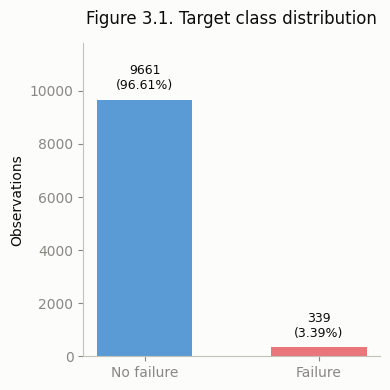

In [54]:
# Finding 3.1 (single-variable). Target class imbalance

counts = df[target_col].value_counts().sort_index()
pct = df[target_col].value_counts(normalize=True).sort_index() * 100
imbalance_ratio = counts[0] / counts[1]
print("Class counts:\n", counts)
print("Class %:\n", pct.round(2))
print(f"Imbalance ratio (no-failure : failure) = {imbalance_ratio:.1f} : 1")

fig, ax = plt.subplots(figsize=(4, 4))
ax.grid(False)
ax.bar(['No failure', 'Failure'], counts.values,
       color=[COLOR_NO_FAILURE, COLOR_FAILURE], width=0.55)
ax.set_ylim(0, counts.values.max() * 1.22)   # headroom so labels/title never collide with bars
for i, v in enumerate(counts.values):
    ax.text(i, v + counts.values.max() * 0.03, f"{v}\n({pct.values[i]:.2f}%)",
            ha='center', va='bottom', fontsize=9)
ax.set_ylabel("Observations")
ax.set_title("Figure 3.1. Target class distribution")
plt.tight_layout()
savefig("fig3_1_target_distribution.png")
plt.show()

Tool wear [min] by class:
                    mean  median    std
Machine failure                       
0                106.69   107.0  62.95
1                143.78   165.0  72.76


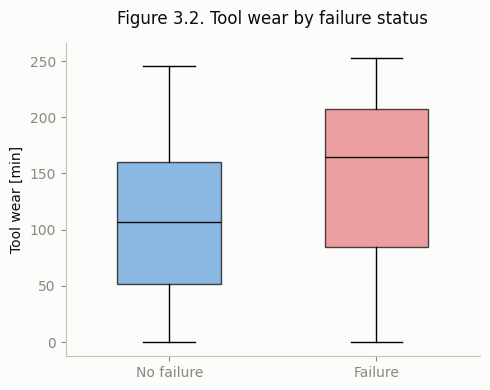

In [55]:
# Finding 3.2 (single-variable). Tool wear by failure status

wear_by_class = df.groupby(target_col)['Tool wear [min]'].agg(['mean', 'median', 'std'])
print("Tool wear [min] by class:\n", wear_by_class.round(2))

fig, ax = plt.subplots(figsize=(5, 4))
ax.grid(False)
box_data = [df.loc[df[target_col] == 0, 'Tool wear [min]'],
            df.loc[df[target_col] == 1, 'Tool wear [min]']]
bp = ax.boxplot(box_data, tick_labels=['No failure', 'Failure'], patch_artist=True,
                 widths=0.5, medianprops=dict(color=TEXT_PRIMARY))
for patch, color in zip(bp['boxes'], [COLOR_NO_FAILURE, COLOR_FAILURE]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel("Tool wear [min]")
ax.set_title("Figure 3.2. Tool wear by failure status")
plt.tight_layout()
savefig("fig3_2_toolwear_by_failure.png")
plt.show()



      n_observations  n_failures  failure_rate  failure_rate_pct
Type                                                            
H               1003          21      0.020937              2.09
L               6000         235      0.039167              3.92
M               2997          83      0.027694              2.77


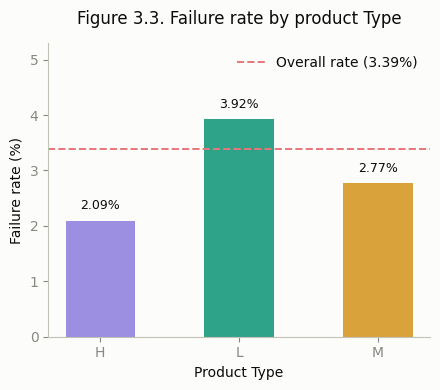

In [56]:
# Finding 3.3 (single-variable, categorical). Failure rate by product Type

type_summary = df.groupby('Type')[target_col].agg(['count', 'sum', 'mean'])
type_summary.columns = ['n_observations', 'n_failures', 'failure_rate']
type_summary['failure_rate_pct'] = (type_summary['failure_rate'] * 100).round(2)
type_summary = type_summary.sort_index()
print(type_summary)

fig, ax = plt.subplots(figsize=(4.5, 4))
ax.grid(False)
bar_colors = [TYPE_COLORS[t] for t in type_summary.index]
ax.bar(type_summary.index, type_summary['failure_rate_pct'], color=bar_colors, width=0.5)
overall_rate = df[target_col].mean() * 100
ax.axhline(overall_rate, color=COLOR_FAILURE, linestyle='--', linewidth=1.4,
           label=f"Overall rate ({overall_rate:.2f}%)")
ax.set_ylim(0, type_summary['failure_rate_pct'].max() * 1.35)
for i, (idx, row) in enumerate(type_summary.iterrows()):
    ax.text(i, row['failure_rate_pct'] + type_summary['failure_rate_pct'].max() * 0.04,
            f"{row['failure_rate_pct']:.2f}%", ha='center', va='bottom', fontsize=9)
ax.set_ylabel("Failure rate (%)")
ax.set_xlabel("Product Type")
ax.set_title("Figure 3.3. Failure rate by product Type")
ax.legend(frameon=False, loc='upper right')
plt.tight_layout()
savefig("fig3_3_failure_rate_by_type.png")
plt.show()


                         Air temperature [K]  Process temperature [K]  \
Air temperature [K]                    1.000                    0.876   
Process temperature [K]                0.876                    1.000   
Rotational speed [rpm]                 0.023                    0.019   
Torque [Nm]                           -0.014                   -0.014   
Tool wear [min]                        0.014                    0.013   

                         Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  
Air temperature [K]                       0.023       -0.014            0.014  
Process temperature [K]                   0.019       -0.014            0.013  
Rotational speed [rpm]                    1.000       -0.875            0.000  
Torque [Nm]                              -0.875        1.000           -0.003  
Tool wear [min]                           0.000       -0.003            1.000  


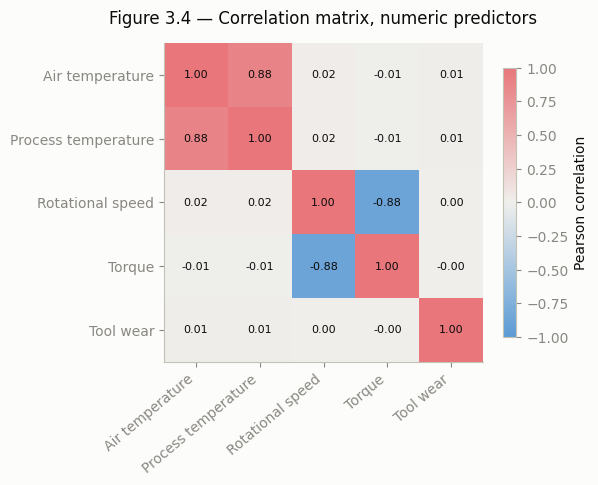

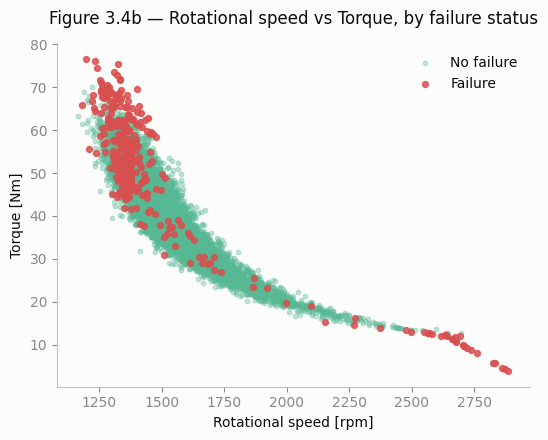

In [57]:
# Finding 3.4 (MULTI-variable) -- Correlation among numeric predictors

corr_matrix = df[numeric_cols].corr()
print(corr_matrix.round(3))

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr_matrix.values, cmap=DIVERGING_CMAP, vmin=-1, vmax=1)
ax.set_xticks(range(len(numeric_cols)))
ax.set_yticks(range(len(numeric_cols)))
short_labels = [c.split(' [')[0] for c in numeric_cols]
ax.set_xticklabels(short_labels, rotation=40, ha='right')
ax.set_yticklabels(short_labels)
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        ax.text(j, i, f"{corr_matrix.values[i, j]:.2f}", ha='center', va='center',
                fontsize=8, color=TEXT_PRIMARY)
fig.colorbar(im, ax=ax, shrink=0.8, label="Pearson correlation")
ax.set_title("Figure 3.4 — Correlation matrix, numeric predictors")
plt.tight_layout()
savefig("fig3_4_correlation_heatmap.png")
plt.show()

# Scatter: Rotational speed vs Torque, colored by failure status
fig, ax = plt.subplots(figsize=(5.5, 4.5))
for cls, color, label in [(0, COLOR_NO_FAILURE_STRONG, 'No failure'), (1, COLOR_FAILURE_STRONG, 'Failure')]:
    subset = df[df[target_col] == cls]
    ax.scatter(subset['Rotational speed [rpm]'], subset['Torque [Nm]'],
               s=10 if cls == 0 else 18, alpha=0.35 if cls == 0 else 0.85,
               color=color, label=label)
ax.set_xlabel("Rotational speed [rpm]")
ax.set_ylabel("Torque [Nm]")
ax.set_title("Figure 3.4b — Rotational speed vs Torque, by failure status")
ax.legend(frameon=False)
plt.tight_layout()
savefig("fig3_4b_speed_vs_torque.png")
plt.show()

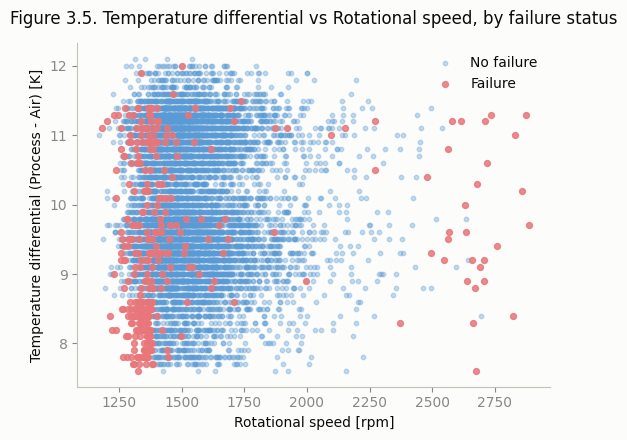

Rows in risk zone (speed<1400rpm AND temp_diff<8.6K): 150 (1.50% of data)
Failure rate inside risk zone:  77.33%
Failure rate outside risk zone: 2.26%
Overall failure rate:           3.39%
Lift (zone rate / overall rate): 22.81x


In [50]:
# Finding 3.5 (MULTI-variable). Temperature differential x Rotational speed

temp_diff = df['Process temperature [K]'] - df['Air temperature [K]']

fig, ax = plt.subplots(figsize=(5.5, 4.5))
for cls, color, label in [(0, COLOR_NO_FAILURE, 'No failure'), (1, COLOR_FAILURE, 'Failure')]:
    mask = df[target_col] == cls
    ax.scatter(df.loc[mask, 'Rotational speed [rpm]'], temp_diff[mask],
               s=10 if cls == 0 else 18, alpha=0.35 if cls == 0 else 0.85,
               color=color, label=label)
ax.set_xlabel("Rotational speed [rpm]")
ax.set_ylabel("Temperature differential (Process - Air) [K]")
ax.set_title("Figure 3.5. Temperature differential vs Rotational speed, by failure status")
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("fig3_5_tempdiff_vs_speed.png", dpi=150)
plt.show()

# Quantify the apparent low-speed / low-temp-diff risk zone with a lift calculation
low_speed = df['Rotational speed [rpm]'] < 1400
low_tempdiff = temp_diff < 8.6
risk_zone = low_speed & low_tempdiff

overall_failure_rate = df[target_col].mean()
zone_failure_rate = df.loc[risk_zone, target_col].mean()
outside_zone_failure_rate = df.loc[~risk_zone, target_col].mean()
lift = zone_failure_rate / overall_failure_rate

print(f"Rows in risk zone (speed<1400rpm AND temp_diff<8.6K): {risk_zone.sum()} ({risk_zone.mean()*100:.2f}% of data)")
print(f"Failure rate inside risk zone:  {zone_failure_rate*100:.2f}%")
print(f"Failure rate outside risk zone: {outside_zone_failure_rate*100:.2f}%")
print(f"Overall failure rate:           {overall_failure_rate*100:.2f}%")
print(f"Lift (zone rate / overall rate): {lift:.2f}x")


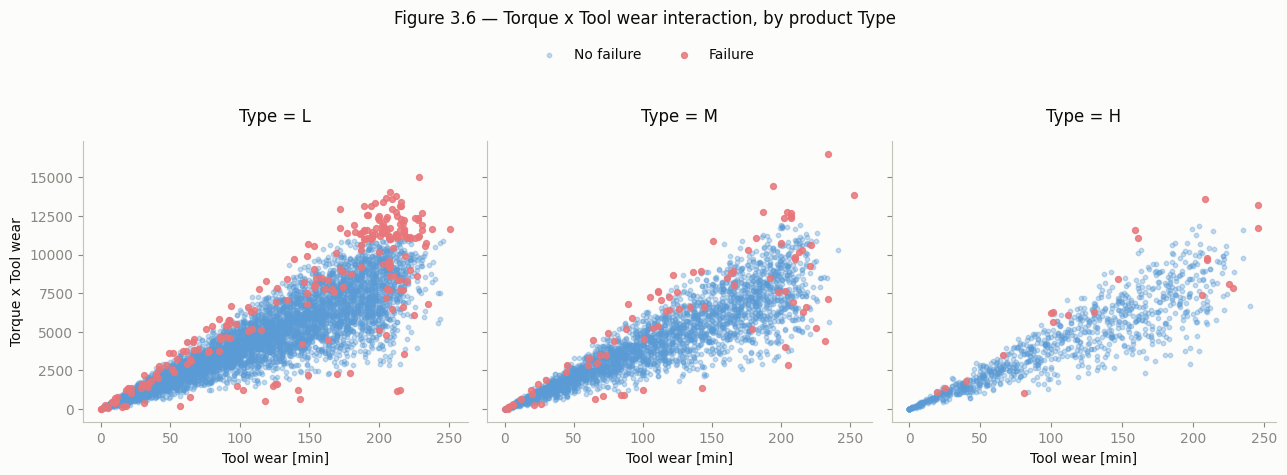

Correlation(Torque x Tool wear, Machine failure) overall: 0.190
  Type=L: correlation=0.226, n=6000, 99th pct of product=11346
  Type=M: correlation=0.117, n=2997, 99th pct of product=10926
  Type=H: correlation=0.155, n=1003, 99th pct of product=10752


In [51]:
# Finding 3.6 (MULTI-variable) -- Torque x Tool wear interaction, by Type

torque_wear_product = df['Torque [Nm]'] * df['Tool wear [min]']

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), sharey=True)
for ax, t in zip(axes, ['L', 'M', 'H']):
    mask_type = df['Type'] == t
    for cls, color, label in [(0, COLOR_NO_FAILURE, 'No failure'), (1, COLOR_FAILURE, 'Failure')]:
        mask = mask_type & (df[target_col] == cls)
        ax.scatter(df.loc[mask, 'Tool wear [min]'], torque_wear_product[mask],
                   s=10 if cls == 0 else 18, alpha=0.35 if cls == 0 else 0.85,
                   color=color, label=label if t == 'L' else None)
    ax.set_title(f"Type = {t}")
    ax.set_xlabel("Tool wear [min]")
axes[0].set_ylabel("Torque x Tool wear")
fig.legend(loc='upper center', ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.06))
fig.suptitle("Figure 3.6. Torque x Tool wear interaction, by product Type", y=1.12)
plt.tight_layout()
plt.savefig("fig3_6_torque_wear_by_type.png", dpi=150, bbox_inches='tight')
plt.show()

# Correlation of the interaction term with the target, overall and by Type
corr_overall = np.corrcoef(torque_wear_product, df[target_col])[0, 1]
print(f"Correlation(Torque x Tool wear, Machine failure) overall: {corr_overall:.3f}")

for t in ['L', 'M', 'H']:
    mask_type = df['Type'] == t
    c = np.corrcoef(torque_wear_product[mask_type], df.loc[mask_type, target_col])[0, 1]
    q99 = torque_wear_product[mask_type].quantile(0.99)
    print(f"  Type={t}: correlation={c:.3f}, n={mask_type.sum()}, 99th pct of product={q99:.0f}")
